In [18]:

#  Data Preprocessing & EDA
# Covers:
# 1. Handling Missing Data
# 2. Encoding Categorical Variables
# 3. Outlier Removal
# 4. Normalization / Scaling of numeric features
# 5.Class imbalance handling
# 6. Feature Engineering (Selection + Dimensionality Reduction)


#  Data Preprocessing & EDA on cardio_train.csv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

# Load dataset
df = pd.read_csv("cardio_train.csv", sep=";")
print("Dataset shape:", df.shape)
df.head()



Dataset shape: (70000, 13)


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Missing values per column:
 id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64


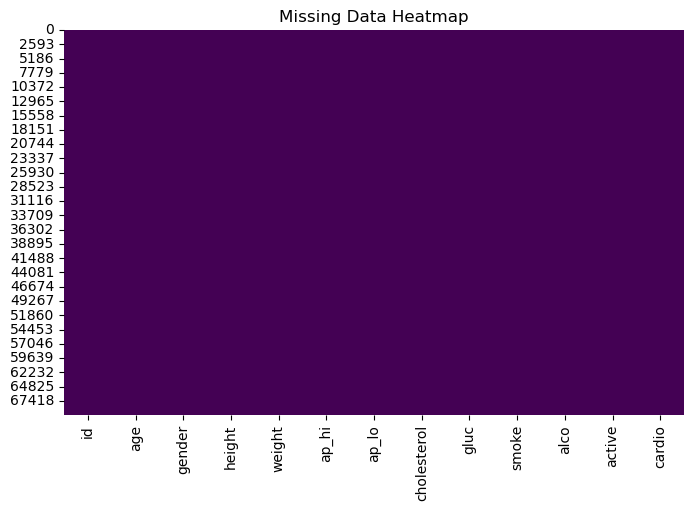

Missing values (%):
 id             0.0
age            0.0
gender         0.0
height         0.0
weight         0.0
ap_hi          0.0
ap_lo          0.0
cholesterol    0.0
gluc           0.0
smoke          0.0
alco           0.0
active         0.0
cardio         0.0
dtype: float64
✅ No missing values found in this dataset.


In [19]:
# 1. Handling Missing Data
# Check missing values
print("Missing values per column:\n", df.isnull().sum())

# Visualize missing values (should show none)
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

# Percentage of missing values
missing_percent = (df.isnull().sum() / len(df)) * 100
print("Missing values (%):\n", missing_percent)

if df.isnull().sum().sum() == 0:
    print("✅ No missing values found in this dataset.")
else:
    print("⚠️ Missing values detected, need to impute/drop.")




Dataset shape after outlier removal: (68749, 13)


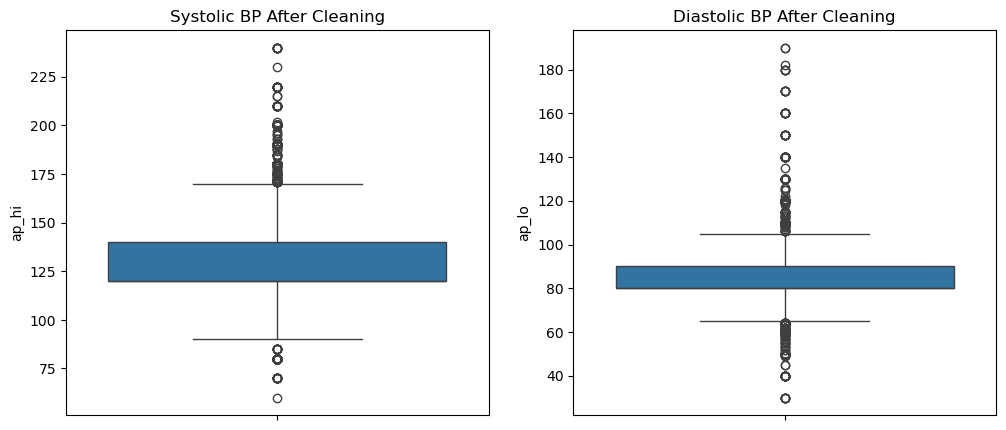

In [20]:



# 2. Outlier Removal
# Remove height outliers (realistic range: 100–250 cm)
df = df[(df['height'] >= 100) & (df['height'] <= 250)]

# Remove weight outliers (realistic range: 30–200 kg)
df = df[(df['weight'] >= 30) & (df['weight'] <= 200)]

# Remove BP outliers (ap_hi = systolic, ap_lo = diastolic)
df = df[(df['ap_hi'] >= 50) & (df['ap_hi'] <= 250)]
df = df[(df['ap_lo'] >= 30) & (df['ap_lo'] <= 200)]

print("Dataset shape after outlier removal:", df.shape)

# Boxplots to confirm cleaning
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(y=df['ap_hi'], ax=axes[0])
axes[0].set_title("Systolic BP After Cleaning")
sns.boxplot(y=df['ap_lo'], ax=axes[1])
axes[1].set_title("Diastolic BP After Cleaning")
plt.show()






After encoding: (68749, 15)


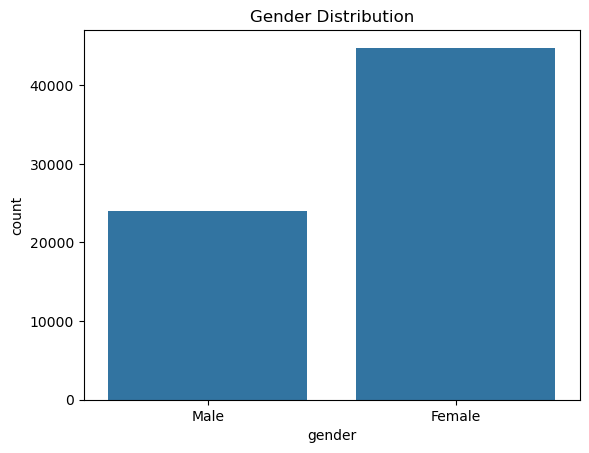

In [21]:

# 3. Encoding Categorical Variables
# Gender: 1 = Female, 2 = Male
df['gender'] = df['gender'].map({1: "Female", 2: "Male"})

# Cholesterol & Gluc are ordinal categorical: 1 = normal, 2 = above normal, 3 = well above normal
df['cholesterol'] = df['cholesterol'].map({1: "Normal", 2: "Above Normal", 3: "Well Above Normal"})
df['gluc'] = df['gluc'].map({1: "Normal", 2: "Above Normal", 3: "Well Above Normal"})

# Convert categorical to dummy variables (One-Hot Encoding)
df_encoded = pd.get_dummies(df, columns=['gender','cholesterol','gluc'], drop_first=True)

print("After encoding:", df_encoded.shape)
df_encoded.head()

# Countplot for gender distribution
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()


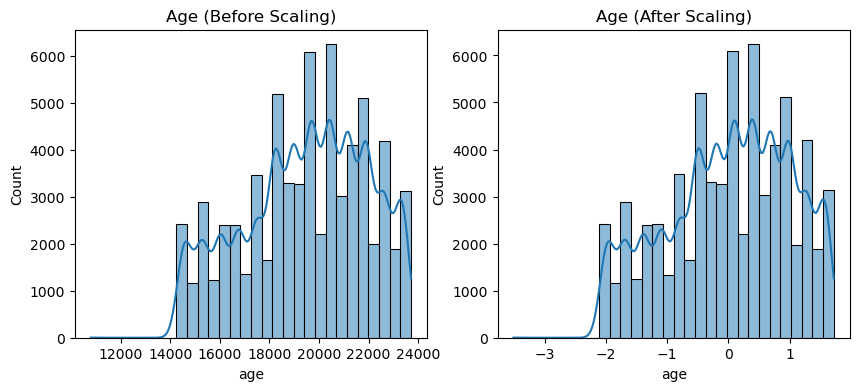

In [22]:
# 4. Normalization / Scaling
scaler = StandardScaler()
cols_to_scale = ['age','height','weight','ap_hi','ap_lo']

df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

# Compare distributions (Age before vs after scaling)
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(df['age'], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Age (Before Scaling)")
sns.histplot(df_scaled['age'], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Age (After Scaling)")
plt.show()


Class distribution before: Counter({0: 34723, 1: 34026})
Class distribution after: Counter({0: 34723, 1: 34723})


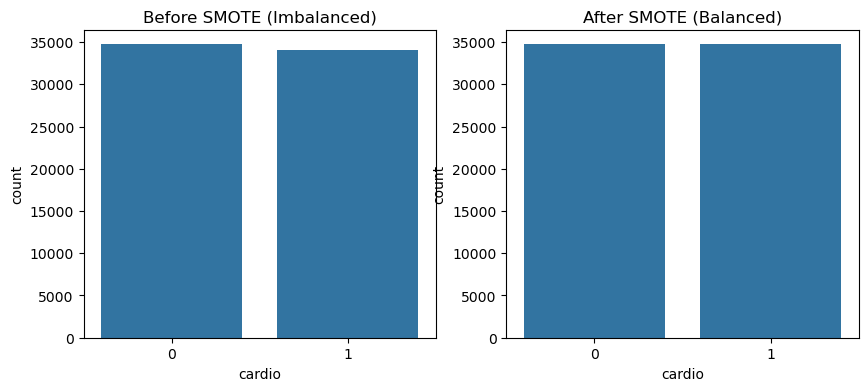

In [23]:
#5.Class imbalance handling

from collections import Counter
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

# Use encoded dataset for SMOTE (numeric only)
df_encoded = pd.get_dummies(df, columns=['gender','cholesterol','gluc'], drop_first=True)

X = df_encoded.drop(columns=['cardio'])
y = df_encoded['cardio']

# Check imbalance before SMOTE
print("Class distribution before:", Counter(y))

# Apply SMOTE
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print("Class distribution after:", Counter(y_res))

# Visualization: before vs after
fig, axes = plt.subplots(1, 2, figsize=(10,4))

sns.countplot(x=y, ax=axes[0])
axes[0].set_title("Before SMOTE (Imbalanced)")

sns.countplot(x=y_res, ax=axes[1])
axes[1].set_title("After SMOTE (Balanced)")

plt.show()



Selected Features: Index(['age', 'weight', 'ap_hi', 'ap_lo', 'age_years', 'BMI',
       'cholesterol_Normal', 'cholesterol_Well Above Normal'],
      dtype='object')


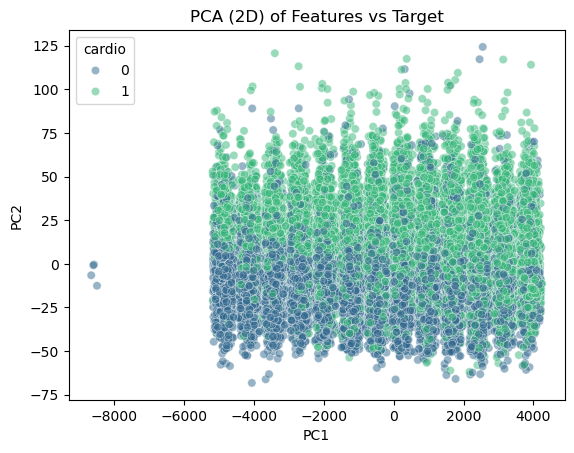

In [24]:

# 6. Feature Engineering (Selection + Dimensionality Reduction)
# Convert age from days → years
df['age_years'] = (df['age'] / 365).astype(int)

# Add BMI
df['BMI'] = df['weight'] / ( (df['height']/100) ** 2 )

# Re-encode categorical variables
df_fe = pd.get_dummies(df, columns=['gender','cholesterol','gluc'], drop_first=True)

# Feature Selection (ANOVA F-test)
X = df_fe.drop(columns=['id','cardio'])
y = df_fe['cardio']

selector = SelectKBest(score_func=f_classif, k=8)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
print("Selected Features:", selected_features)

# PCA (reduce to 2 components for visualization)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1','PC2'])
df_pca['cardio'] = y.values

sns.scatterplot(x='PC1', y='PC2', hue='cardio', data=df_pca, alpha=0.5, palette="viridis")
plt.title("PCA (2D) of Features vs Target")
plt.show()

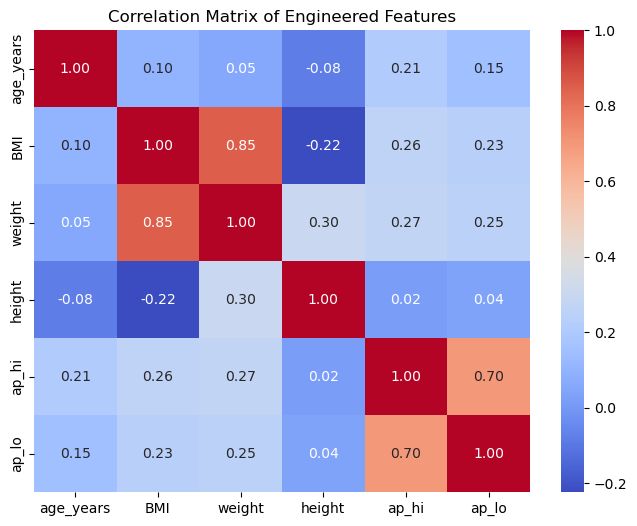

In [16]:
#EDA visualization : Correlation matrix

import seaborn as sns
import matplotlib.pyplot as plt


# Import libraries
import matplotlib.pyplot as plt
import seaborn as sns


# Feature Engineering
df['age_years'] = (df['age'] / 365).astype(int)   # Convert age in days → years
df['BMI'] = df['weight'] / ((df['height']/100) ** 2)   # Calculate BMI

# Correlation Heatmap of Engineered Features
plt.figure(figsize=(8,6))
sns.heatmap(
    df[['age_years','BMI','weight','height','ap_hi','ap_lo']].corr(), 
    annot=True, cmap="coolwarm", fmt=".2f"
)
plt.title("Correlation Matrix of Engineered Features")
plt.show()



In [25]:
# Final dataset (after preprocessing and feature engineering)
final_df = df_fe.copy()

# Save to CSV
final_df.to_csv("processed_cardio_dataset.csv", index=False)

print("✅ Final preprocessed dataset saved as processed_cardio_dataset.csv")

✅ Final preprocessed dataset saved as processed_cardio_dataset.csv
